# Proyecto Final: Transformación y Modelado de Indicadores Socioeconómicos en Latinoamérica

**Curso:** CC3074 - Minería de Datos  
**Framework:** CRISP-DM - Fase 3: Preparación de Datos  
**Fuente de datos:** CEPALSTAT - Observatorio de Desarrollo Digital (ODD)  
**Indicador:** Personas usuarias de Internet por grupo etario, países seleccionados de América Latina y el Caribe  

**Integrantes:**

- Cristian Túnchez (231359)  
- Dulce Ambrosio (231143)  
- Daniel Chet (231177)  
- Javier Linares (231135)  

## Semana 2 - Transformación del Conjunto de Datos: Construcción del Conjunto Analítico

---
### Contexto y Objetivo

En la Semana 1 se realizó el Análisis Exploratorio de Datos (EDA) sobre los **870 registros × 8 columnas** publicados por CEPAL. Se identificaron los siguientes hallazgos críticos para la fase de preparación de datos:

- **Cuatro columnas no informativas:** `indicator`, `unit`, `source_id` (constantes) y `notes_ids` (100% nula).
- **Panel desbalanceado:** sólo el **49.3%** de las combinaciones país × año × grupo etario están reportadas (870 de 1,764 posibles; 145 de 294 pares país-año).
- **Formato largo (long/tidy):** una única columna numérica `value` con dimensión categórica `Grupos etarios Uso Internet`, lo que dificulta el análisis multivariado.
- **Tipos de datos heterogéneos:** nombres de columnas con caracteres especiales y dobles guiones bajos.

**Objetivo de la Semana 2:** ejecutar la **Fase 3 completa de CRISP-DM (Preparación de Datos)**, dejando el conjunto de datos listo para la Fase de Modelado en la Semana 3.

**Configuración del entorno e importación de librerías**

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from scipy import stats as sp_stats
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

# Configuracion visual
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

# Paleta personalizada para grupos etarios (de joven a mayor)
PALETA_EDAD = {
    'edad de medicion a 17 años': '#2196F3',
    '18 a 25 años de edad': '#4CAF50',
    '26 a 50 años de edad': '#FF9800',
    '51 a 65 años': '#F44336',
    '66 años en adelante': '#9C27B0',
    'Total': '#607D8B'
}

ORDEN_EDAD = [
    'edad de medicion a 17 años',
    '18 a 25 años de edad',
    '26 a 50 años de edad',
    '51 a 65 años',
    '66 años en adelante',
    'Total'
]

# Etiquetas cortas para gráficos
ETIQUETAS_CORTAS = {
    'edad de medicion a 17 años': '<=17 años',
    '18 a 25 años de edad': '18-25',
    '26 a 50 años de edad': '26-50',
    '51 a 65 años': '51-65',
    '66 años en adelante': '66+',
    'Total': 'Total'
}

print('Entorno configurado correctamente.')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')

Entorno configurado correctamente.
pandas: 3.0.0
numpy: 2.4.2


**Carga de datos desde el archivo Excel (hoja `datos`)**

In [ ]:
df = pd.read_excel('data.xlsx', sheet_name='datos')

print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'\nColumnas originales:')
for c in df.columns:
    print(f'  - {c}')
print(f'\nPrimeras filas:')
display(df.head())

Dataset cargado: 870 filas x 8 columnas

Columnas originales:
  - indicator
  - País__ESTANDAR
  - Grupos etarios Uso Internet
  - Años__ESTANDAR
  - value
  - unit
  - notes_ids
  - source_id

Primeras filas:


,indicator,País__ESTANDAR,Grupos etarios Uso Internet,Años__ESTANDAR,value,unit,notes_ids,source_id
0,Personas usuarias de Internet por grupo etario...,Argentina,edad de medicion a 17 años,2016,75.9,Porcentaje sobre el total de personas en cada ...,NaN,9353
1,Personas usuarias de Internet por grupo etario...,Argentina,edad de medicion a 17 años,2017,75.9,Porcentaje sobre el total de personas en cada ...,NaN,9353
2,Personas usuarias de Internet por grupo etario...,Argentina,edad de medicion a 17 años,2018,78.5,Porcentaje sobre el total de personas en cada ...,NaN,9353
3,Personas usuarias de Internet por grupo etario...,Argentina,edad de medicion a 17 años,2019,78.9,Porcentaje sobre el total de personas en cada ...,NaN,9353
4,Personas usuarias de Internet por grupo etario...,Argentina,edad de medicion a 17 años,2020,87.5,Porcentaje sobre el total de personas en cada ...,NaN,9353


**Recapitulación del estado inicial**

In [ ]:
print('=' * 70)
print('ESTADO INICIAL DEL DATASET')
print('=' * 70)
print(f'\nDimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'\nValores únicos por columna:')
print('─' * 50)
for col in df.columns:
    n_unique = df[col].nunique()
    n_null = df[col].isna().sum()
    print(f'  {col:35s}  únicos: {n_unique:4d}  nulos: {n_null:4d}')

print(f'\nMemoria utilizada: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')

ESTADO INICIAL DEL DATASET

Dimensiones: 870 filas x 8 columnas

Valores únicos por columna:
──────────────────────────────────────────────────
  indicator                            únicos:    1  nulos:    0
  País__ESTANDAR                       únicos:   14  nulos:    0
  Grupos etarios Uso Internet          únicos:    6  nulos:    0
  Años__ESTANDAR                       únicos:   21  nulos:    0
  value                                únicos:  577  nulos:    0
  unit                                 únicos:    1  nulos:    0
  notes_ids                            únicos:    0  nulos:  870
  source_id                            únicos:    1  nulos:    0

Memoria utilizada: 495.7 KB


---
### 1. Limpieza Preliminar

Antes de pivotear, eliminamos las columnas no informativas identificadas en la Semana 1 y normalizamos los nombres de las columnas restantes a un esquema en español, en minúsculas y sin caracteres problemáticos para CSV.

**Eliminación de columnas constantes y nulas**

In [ ]:
COLUMNAS_NO_INFORMATIVAS = ['indicator', 'unit', 'source_id', 'notes_ids']

print('Columnas a eliminar y razón:')
print('─' * 50)
for col in COLUMNAS_NO_INFORMATIVAS:
    n_unique = df[col].nunique(dropna=False)
    n_null = df[col].isna().sum()
    if n_null == len(df):
        razon = '100% nula'
    elif n_unique == 1:
        razon = f'constante (valor único)'
    else:
        razon = '?'
    print(f'  {col:15s}  →  {razon}')

df = df.drop(columns=COLUMNAS_NO_INFORMATIVAS)
print(f'\nForma tras eliminar columnas: {df.shape}')

Columnas a eliminar y razón:
──────────────────────────────────────────────────
  indicator        →  constante (valor único)
  unit             →  constante (valor único)
  source_id        →  constante (valor único)
  notes_ids        →  100% nula

Forma tras eliminar columnas: (870, 4)


**Renombrado de columnas a snake_case en español**

In [ ]:
MAPEO_COLUMNAS = {
    'País__ESTANDAR': 'pais',
    'Grupos etarios Uso Internet': 'grupo_etario',
    'Años__ESTANDAR': 'año',
    'value': 'valor'
}

print('Mapeo de renombramiento:')
print('─' * 50)
for original, nuevo in MAPEO_COLUMNAS.items():
    print(f'  {original:35s}  →  {nuevo}')

df = df.rename(columns=MAPEO_COLUMNAS)
df['año'] = df['año'].astype(int)

print(f'\nTipos de datos tras limpieza:')
print(df.dtypes)
print(f'\nMuestra:')
display(df.head())

Mapeo de renombramiento:
──────────────────────────────────────────────────
  País__ESTANDAR                       →  pais
  Grupos etarios Uso Internet          →  grupo_etario
  Años__ESTANDAR                       →  año
  value                                →  valor

Tipos de datos tras limpieza:
pais                str
grupo_etario        str
año               int64
valor           float64
dtype: object

Muestra:


,pais,grupo_etario,año,valor
0,Argentina,edad de medicion a 17 años,2016,75.9
1,Argentina,edad de medicion a 17 años,2017,75.9
2,Argentina,edad de medicion a 17 años,2018,78.5
3,Argentina,edad de medicion a 17 años,2019,78.9
4,Argentina,edad de medicion a 17 años,2020,87.5


**Justificación de las decisiones de limpieza**

| Columna eliminada | Razón |
|---|---|
| `indicator` | Constante: contiene el mismo nombre del indicador en todas las filas. |
| `unit` | Constante: todas las observaciones están en "Porcentaje sobre el total de personas en cada grupo etario". |
| `source_id` | Constante: todas las filas referencian la misma fuente (ID 9353). |
| `notes_ids` | 100% nula: ninguna observación tiene notas asociadas. |

| Columna renombrada | Motivo |
|---|---|
| `País__ESTANDAR` → `pais` | Eliminar doble guión bajo y mayúsculas; estandarizar a snake_case. |
| `Grupos etarios Uso Internet` → `grupo_etario` | Eliminar espacios; nombre más conciso y compatible con CSV/SQL. |
| `Años__ESTANDAR` → `año` | Eliminar doble guión bajo; nombre semántico. |
| `value` → `valor` | Coherencia con resto de columnas en español. |

---
### 2. Pivoteo de Datos: de Formato Largo a Ancho

El dataset original está en **formato largo (long/tidy)**: cada fila es una observación (`pais`, `grupo_etario`, `año`) con un único valor numérico. Para análisis multivariado, modelado y visualización es preferible un **formato ancho (wide)** donde cada fila representa una unidad de observación (par `pais`-`año`) y cada columna representa un indicador (un grupo etario).

Este pivoteo convierte un único indicador con dimensión categórica en **6 indicadores numéricos** independientes, listos para análisis correlacional, clustering y modelado supervisado en fases posteriores.

**Pivote: index=(pais, año), columns=grupo_etario, values=valor**

In [ ]:
df_wide = df.pivot_table(
    index=['pais', 'año'],
    columns='grupo_etario',
    values='valor',
    aggfunc='first'
).reset_index()
df_wide.columns.name = None

# Reordenar columnas siguiendo la progresión etaria definida en ORDEN_EDAD
df_wide = df_wide[['pais', 'año'] + ORDEN_EDAD]

print(f'Forma tras el pivoteo: {df_wide.shape}')
print(f'\nCombinaciones (pais, año) observadas: {df_wide.shape[0]}')
print(f'Indicadores generados (columnas de grupo etario): {len(ORDEN_EDAD)}')
print(f'\nColumnas resultantes:')
for c in df_wide.columns:
    print(f'  - {c}')
print(f'\nMuestra del DataFrame pivoteado:')
display(df_wide.head(10))

Forma tras el pivoteo: (145, 8)

Combinaciones (pais, año) observadas: 145
Indicadores generados (columnas de grupo etario): 6

Columnas resultantes:
  - pais
  - año
  - edad de medicion a 17 años
  - 18 a 25 años de edad
  - 26 a 50 años de edad
  - 51 a 65 años
  - 66 años en adelante
  - Total

Muestra del DataFrame pivoteado:


,pais,año,edad de medicion a 17 años,18 a 25 años de edad,26 a 50 años de edad,51 a 65 años,66 años en adelante,Total
0,Argentina,2016,75.9,86.4,82.0,60.9,28.6,71.1
1,Argentina,2017,75.9,89.7,85.6,67.6,34.0,74.4
2,Argentina,2018,78.5,90.2,88.1,73.8,39.7,77.7
3,Argentina,2019,78.9,92.0,89.6,77.3,46.1,80.0
4,Argentina,2020,87.5,95.0,91.9,80.6,54.5,85.6
5,Argentina,2021,86.9,94.9,94.2,86.9,57.4,87.2
6,Argentina,2022,86.5,96.8,95.2,88.4,62.7,88.5
7,Bolivia (Estado Plurinacional de),2009,30.2,56.1,26.8,11.1,2.5,29.5
8,Bolivia (Estado Plurinacional de),2012,39.1,62.4,33.1,14.8,3.7,35.5
9,Bolivia (Estado Plurinacional de),2013,38.9,66.6,36.8,17.6,5.2,37.1


**Verificación: ausencia de duplicados y consistencia del pivote**

In [ ]:
print('=' * 70)
print('VALIDACIÓN DEL PIVOTE')
print('=' * 70)

# Verificar que no hubo agregación silenciosa
duplicados = df.duplicated(subset=['pais', 'año', 'grupo_etario']).sum()
print(f'\nDuplicados en (pais, año, grupo_etario) en formato largo: {duplicados}')

# Reconstrucción de control: filas largas vs (filas wide × 6 grupos)
esperado = len(df_wide) * len(ORDEN_EDAD)
print(f'\nObservaciones largas: {len(df)}')
print(f'Filas wide × 6 grupos:  {esperado}')
print(f'¿Coinciden?            {len(df) == esperado}')

# Verificar conteo de NaN dentro del pivote (no deberían existir si los grupos están balanceados)
print(f'\nNaN por columna en el DataFrame pivoteado:')
print('─' * 50)
print(df_wide.isna().sum().to_string())

VALIDACIÓN DEL PIVOTE

Duplicados en (pais, año, grupo_etario) en formato largo: 0

Observaciones largas: 870
Filas wide × 6 grupos:  870
¿Coinciden?            True

NaN por columna en el DataFrame pivoteado:
──────────────────────────────────────────────────
pais                          0
año                           0
edad de medicion a 17 años    0
18 a 25 años de edad          0
26 a 50 años de edad          0
51 a 65 años                  0
66 años en adelante           0
Total                         0


**Interpretación**: cada par (pais, año), reportado en la fuente, contiene los 6 grupos etarios completos (panel balanceado condicional a observación). Por eso el pivote no introduce NaN dentro de las filas. Los faltantes reales están a nivel de panel: pares (pais, año) ausentes en la fuente, no celdas vacías.

---
### 3. Manejo de Múltiples Indicadores

Tras el pivoteo, las 6 categorías de `grupo_etario` se convierten en **6 columnas-indicador** independientes. En esta sección las renombramos a identificadores limpios (snake_case, ordenados por edad ascendente) y documentamos por qué se conserva `Total` como un indicador separado y no se recalcula a partir de los demás.

**Renombrado de los 6 indicadores y reordenamiento por progresión etaria**

In [ ]:
MAPEO_INDICADORES = {
    'edad de medicion a 17 años': 'pct_uso_<=17',
    '18 a 25 años de edad':        'pct_uso_18_25',
    '26 a 50 años de edad':        'pct_uso_26_50',
    '51 a 65 años':                'pct_uso_51_65',
    '66 años en adelante':         'pct_uso_66_mas',
    'Total':                       'pct_uso_total'
}

df_wide = df_wide.rename(columns=MAPEO_INDICADORES)

INDICADORES = [
    'pct_uso_<=17',
    'pct_uso_18_25',
    'pct_uso_26_50',
    'pct_uso_51_65',
    'pct_uso_66_mas',
    'pct_uso_total'
]
ORDEN_COLUMNAS = ['pais', 'año'] + INDICADORES
df_wide = df_wide[ORDEN_COLUMNAS]

print('Mapeo de indicadores aplicado:')
print('─' * 70)
for original, nuevo in MAPEO_INDICADORES.items():
    print(f'  {original:35s}  →  {nuevo}')

print(f'\nDataFrame con indicadores renombrados:')
display(df_wide.head(10))

Mapeo de indicadores aplicado:
──────────────────────────────────────────────────────────────────────
  edad de medicion a 17 años           →  pct_uso_<=17
  18 a 25 años de edad                 →  pct_uso_18_25
  26 a 50 años de edad                 →  pct_uso_26_50
  51 a 65 años                         →  pct_uso_51_65
  66 años en adelante                  →  pct_uso_66_mas
  Total                                →  pct_uso_total

DataFrame con indicadores renombrados:


,pais,año,pct_uso_<=17,pct_uso_18_25,pct_uso_26_50,pct_uso_51_65,pct_uso_66_mas,pct_uso_total
0,Argentina,2016,75.9,86.4,82.0,60.9,28.6,71.1
1,Argentina,2017,75.9,89.7,85.6,67.6,34.0,74.4
2,Argentina,2018,78.5,90.2,88.1,73.8,39.7,77.7
3,Argentina,2019,78.9,92.0,89.6,77.3,46.1,80.0
4,Argentina,2020,87.5,95.0,91.9,80.6,54.5,85.6
5,Argentina,2021,86.9,94.9,94.2,86.9,57.4,87.2
6,Argentina,2022,86.5,96.8,95.2,88.4,62.7,88.5
7,Bolivia (Estado Plurinacional de),2009,30.2,56.1,26.8,11.1,2.5,29.5
8,Bolivia (Estado Plurinacional de),2012,39.1,62.4,33.1,14.8,3.7,35.5
9,Bolivia (Estado Plurinacional de),2013,38.9,66.6,36.8,17.6,5.2,37.1


**Decisión documentada: conservación de `pct_uso_total` como indicador independiente**

Aunque `pct_uso_total` podría parecer derivable como un promedio ponderado de los grupos etarios desagregados, **se conserva como un indicador separado** por las siguientes razones:

1. **CEPAL lo reporta como medición independiente:** la fuente lo calcula directamente sobre el total poblacional, no como agregación de los subgrupos.
2. **Ausencia de pesos demográficos:** el dataset no incluye la distribución poblacional por grupo etario en cada país-año, por lo que un promedio ponderado correcto no es reproducible con la información disponible.
3. **Valor analítico:** mantener `pct_uso_total` como indicador agregado permite (a) comparar adopción digital total entre países, (b) usarlo como variable objetivo en modelos predictivos posteriores, y (c) detectar inconsistencias entre la medición agregada y la desagregada.

Por lo anterior, en la fase de imputación de la Sección 4 **se aplicará la misma estrategia a los 6 indicadores por igual**, sin reconstruir `pct_uso_total` a partir de los demás.

---
### 4. Manejo de Valores Faltantes

El concepto de "valor faltante" en este dataset opera a **nivel de panel**: no todos los pares `(pais, año)` existen en la fuente. Como se identificó en la Semana 1, la cobertura es del **49.3%** considerando los 6 grupos etarios (870 de 1,764 combinaciones), o equivalentemente **145 de 294 pares país-año** posibles.

Esta sección procede en cinco subetapas:

1. Diagnóstico inicial de la estructura del panel.
2. Completado del grid cartesiano (introduciendo NaN explícitos).
3. Comparación de estrategias de manejo de valores faltantes.
4. Aplicación de la estrategia adoptada (interpolación lineal intra-país).
5. Diagnóstico final y documentación de NaN residuales.

#### 4.1 Diagnóstico Inicial: Estructura del Panel

**Mapa de calor: pares (pais, año) presentes en la fuente**

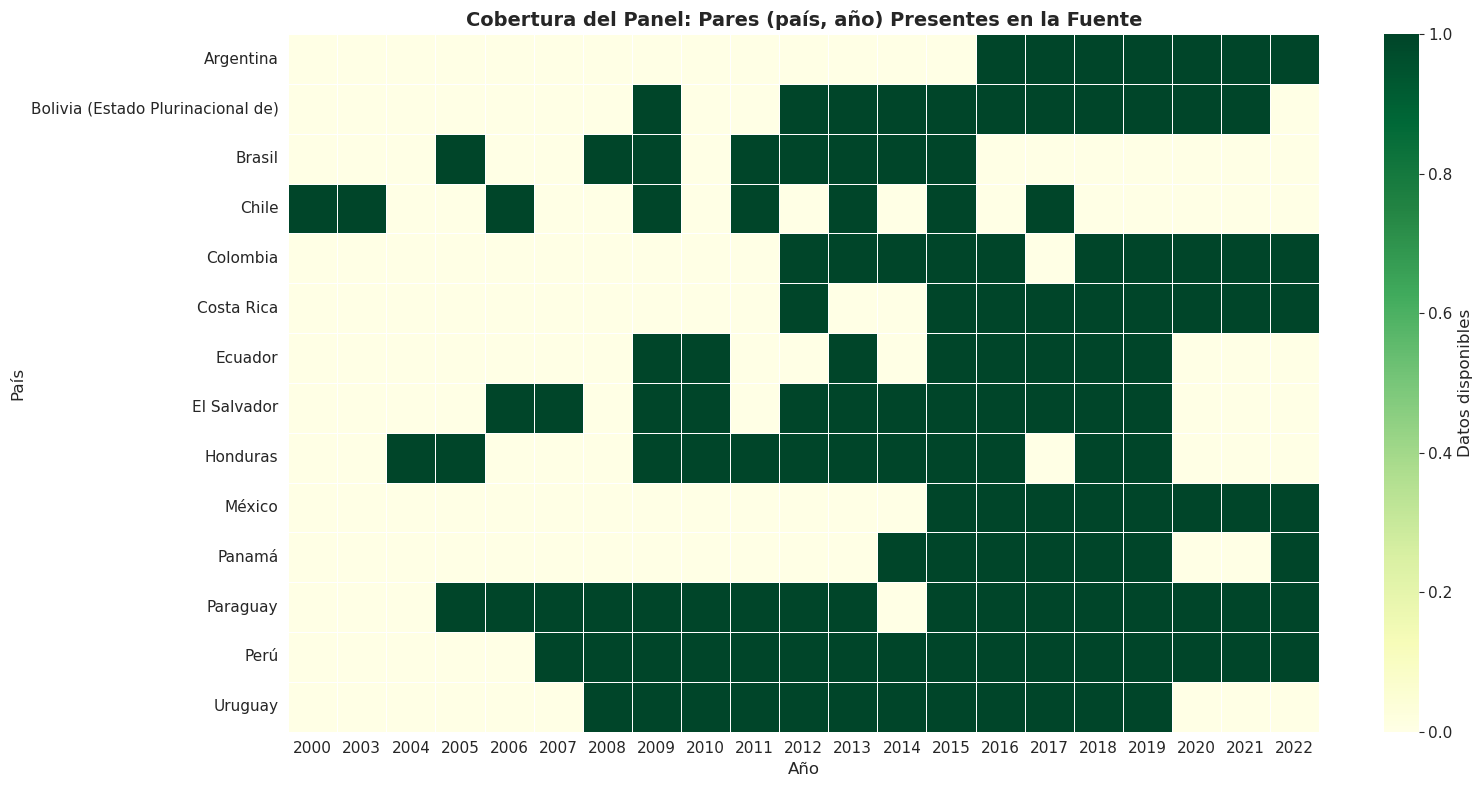

RESUMEN DEL PANEL
  Países:                        14
  Rango temporal:                2000–2022 (23 años)
  Pares (país, año) esperados:   322
  Pares (país, año) observados:  145
  Pares faltantes:               177  (55.0%)


In [ ]:
presencia = (df_wide.assign(presente=1)
                    .pivot_table(index='pais', columns='año', values='presente', aggfunc='first')
                    .fillna(0)
                    .astype(int))

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(presencia, cmap='YlGn', cbar_kws={'label': 'Datos disponibles'},
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Cobertura del Panel: Pares (país, año) Presentes en la Fuente',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('País')
plt.tight_layout()
plt.show()

n_paises = df_wide['pais'].nunique()
rango_años = (int(df_wide['año'].min()), int(df_wide['año'].max()))
n_años = rango_años[1] - rango_años[0] + 1
esperado_pares = n_paises * n_años
observado_pares = len(df_wide)
faltantes = esperado_pares - observado_pares

print('=' * 70)
print('RESUMEN DEL PANEL')
print('=' * 70)
print(f'  Países:                        {n_paises}')
print(f'  Rango temporal:                {rango_años[0]}–{rango_años[1]} ({n_años} años)')
print(f'  Pares (país, año) esperados:   {esperado_pares}')
print(f'  Pares (país, año) observados:  {observado_pares}')
print(f'  Pares faltantes:               {faltantes}  ({faltantes/esperado_pares*100:.1f}%)')

#### 4.2 Completado del Grid Cartesiano

**Reindexar a todas las combinaciones (país × año) y exponer NaN**

In [ ]:
paises = sorted(df_wide['pais'].unique())
años = list(range(rango_años[0], rango_años[1] + 1))

idx_completo = pd.MultiIndex.from_product([paises, años], names=['pais', 'año'])
df_grid = (df_wide.set_index(['pais', 'año'])
                  .reindex(idx_completo)
                  .reset_index())

print(f'Forma tras completar el grid: {df_grid.shape}')
filas_todo_nan = df_grid[INDICADORES].isna().all(axis=1).sum()
print(f'\nFilas con TODOS los indicadores NaN (pares no reportados): {filas_todo_nan}')
print(f'Filas con al menos un valor reportado:                    {len(df_grid) - filas_todo_nan}')

print(f'\nNulos por columna tras reindex:')
print('─' * 50)
print(df_grid.isna().sum().to_string())

print(f'\nMuestra (incluye filas totalmente NaN, p. ej. años sin observar):')
display(df_grid.head(15))

Forma tras completar el grid: (322, 8)

Filas con TODOS los indicadores NaN (pares no reportados): 177
Filas con al menos un valor reportado:                    145

Nulos por columna tras reindex:
──────────────────────────────────────────────────
pais                0
año                 0
pct_uso_<=17      177
pct_uso_18_25     177
pct_uso_26_50     177
pct_uso_51_65     177
pct_uso_66_mas    177
pct_uso_total     177

Muestra (incluye filas totalmente NaN, p. ej. años sin observar):


,pais,año,pct_uso_<=17,pct_uso_18_25,pct_uso_26_50,pct_uso_51_65,pct_uso_66_mas,pct_uso_total
0,Argentina,2000,NaN,NaN,NaN,NaN,NaN,NaN
1,Argentina,2001,NaN,NaN,NaN,NaN,NaN,NaN
2,Argentina,2002,NaN,NaN,NaN,NaN,NaN,NaN
3,Argentina,2003,NaN,NaN,NaN,NaN,NaN,NaN
4,Argentina,2004,NaN,NaN,NaN,NaN,NaN,NaN
5,Argentina,2005,NaN,NaN,NaN,NaN,NaN,NaN
6,Argentina,2006,NaN,NaN,NaN,NaN,NaN,NaN
7,Argentina,2007,NaN,NaN,NaN,NaN,NaN,NaN
8,Argentina,2008,NaN,NaN,NaN,NaN,NaN,NaN
9,Argentina,2009,NaN,NaN,NaN,NaN,NaN,NaN


#### 4.3 Estrategias Consideradas

| # | Estrategia | Acción | Ventaja | Desventaja | Decisión |
|---|---|---|---|---|---|
| A | **Sparse** | Mantener únicamente las 145 filas observadas en la fuente. | No introduce supuestos sobre datos no observados. | Series temporales con cortes; dificulta análisis de tendencias y modelos secuenciales. | Descartada |
| B | **Interpolación lineal intra-país** | Completar el grid (294 filas) e interpolar entre años observados de cada país, sin extrapolar fuera del rango. | Conserva continuidad temporal sin inventar datos en extremos. Asume linealidad sólo localmente. | Asume linealidad entre observaciones consecutivas. | **Adoptada** |
| C | **Drop con cualquier NaN** | Eliminar todo (país, año) con al menos un grupo etario ausente. | Datos 100% reportados. | Pérdida masiva (>50%); sesgo hacia países con cobertura completa. | Descartada |

**Justificación de la elección (B):**

1. La adopción de Internet sigue trayectorias **país-específicas**, por lo que interpolar entre países (cross-section) introduciría sesgo. Interpolar dentro de cada país (intra-país, time-series) es metodológicamente correcto.
2. La opción `limit_area='inside'` de `pandas.DataFrame.interpolate` **garantiza no extrapolar** antes del primer valor observado ni después del último — evitando producir porcentajes negativos o mayores a 100% en extremos.
3. Permite mantener la estructura de panel completa (`294 filas × 8 columnas`) facilitando análisis posteriores, mientras documenta los residuos imposibles de imputar.

#### 4.4 Aplicación: Interpolación Lineal Intra-País

**Imputación con `interpolate(method='linear', limit_area='inside')` por país**

In [ ]:
# Interpolación lineal intra-país sobre los 6 indicadores.
# Se usa groupby.transform en lugar de groupby.apply porque transform garantiza
# que el frame de salida conserva la misma forma, índice y columnas que la entrada
# (incluyendo la columna `pais`). El comportamiento de `apply` sobre la columna
# de grupo cambió entre pandas 2.x y 3.x, lo que hacía frágil cualquier patrón
# basado en apply + reset_index. transform es version-agnostic.

df_interp = df_grid.sort_values(['pais', 'año']).copy()
df_interp[INDICADORES] = (
    df_interp.groupby('pais')[INDICADORES]
             .transform(lambda s: s.interpolate(method='linear', limit_area='inside'))
)

print('Interpolación aplicada por país.')
print(f'\nNulos por columna después de interpolación:')
print('─' * 50)
print(df_interp.isna().sum().to_string())

# Eliminar filas que quedaron 100% NaN (años fuera del rango observado del país)
mascara_todos_nan = df_interp[INDICADORES].isna().all(axis=1)
n_drop = int(mascara_todos_nan.sum())
df_interp = df_interp.loc[~mascara_todos_nan].reset_index(drop=True)

print(f'\nFilas eliminadas (todos los indicadores aún NaN tras interpolación): {n_drop}')
print(f'  Razón: corresponden a años fuera del rango temporal observado de cada país,')
print(f'         donde la opción limit_area="inside" intencionalmente NO extrapola.')

print(f'\nForma tras interpolación + drop: {df_interp.shape}')


Interpolación aplicada por país.

Nulos por columna después de interpolación:
──────────────────────────────────────────────────
pais                0
año                 0
pct_uso_<=17      147
pct_uso_18_25     147
pct_uso_26_50     147
pct_uso_51_65     147
pct_uso_66_mas    147
pct_uso_total     147

Filas eliminadas (todos los indicadores aún NaN tras interpolación): 147
  Razón: corresponden a años fuera del rango temporal observado de cada país,
         donde la opción limit_area="inside" intencionalmente NO extrapola.

Forma tras interpolación + drop: (175, 8)


#### 4.5 Diagnóstico Final

**Mapa de calor post-imputación y conteo de NaN residuales**

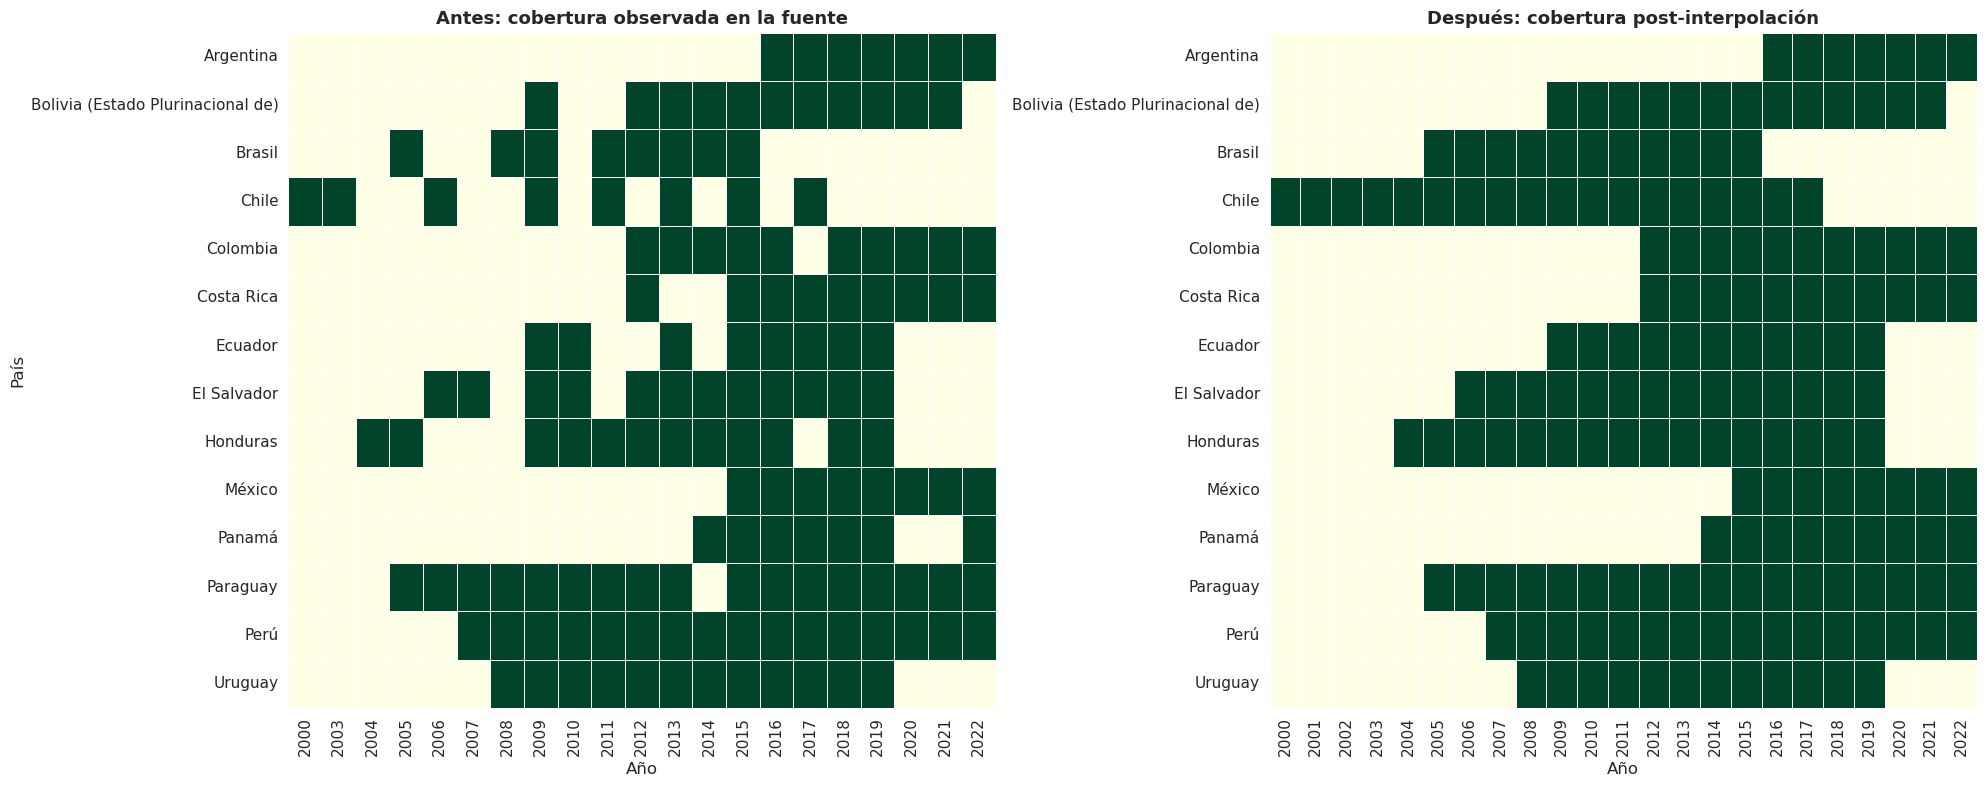

NAN RESIDUALES POR INDICADOR
pct_uso_<=17      0
pct_uso_18_25     0
pct_uso_26_50     0
pct_uso_51_65     0
pct_uso_66_mas    0
pct_uso_total     0

No hay NaN residuales en el dataset.


In [ ]:
# Reconstruir la versión interpolada del grid (sin descartar filas todo-NaN)
# para visualizar la cobertura post-interpolación. Se usa transform — mismo
# patrón que en la celda anterior — para preservar la columna `pais`.
df_grid_interpolated = df_grid.sort_values(['pais', 'año']).copy()
df_grid_interpolated[INDICADORES] = (
    df_grid_interpolated.groupby('pais')[INDICADORES]
                        .transform(lambda s: s.interpolate(method='linear', limit_area='inside'))
)

presencia_post = (df_grid_interpolated
                  .assign(presente=df_grid_interpolated[INDICADORES].notna().any(axis=1).astype(int))
                  .pivot_table(index='pais', columns='año', values='presente', aggfunc='first')
                  .reindex(index=paises, columns=años)
                  .fillna(0)
                  .astype(int))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(presencia, cmap='YlGn', cbar=False, linewidths=0.5, linecolor='white', ax=axes[0])
axes[0].set_title('Antes: cobertura observada en la fuente', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('País')

sns.heatmap(presencia_post, cmap='YlGn', cbar=False, linewidths=0.5, linecolor='white', ax=axes[1])
axes[1].set_title('Después: cobertura post-interpolación', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

nan_residuales = df_interp[INDICADORES].isna().sum()
print('=' * 70)
print('NAN RESIDUALES POR INDICADOR')
print('=' * 70)
print(nan_residuales.to_string())

if nan_residuales.sum() > 0:
    print(f'\nDetalle: pares (país, indicador) con NaN residual (no imputables porque el país')
    print(f'no tiene NINGÚN valor observado para ese indicador):')
    print('─' * 50)
    for ind in INDICADORES:
        paises_nan = df_interp.loc[df_interp[ind].isna(), 'pais'].unique()
        if len(paises_nan) > 0:
            print(f'  {ind:18s}  →  {sorted(paises_nan)}')
else:
    print(f'\nNo hay NaN residuales en el dataset.')
